In [80]:
#1
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
file_path = 'autompg.csv'
df = pd.read_csv(file_path)
print(df.head())


    mpg  cylinders  displacement horsepower  weight  acceleration  year  \
0  18.0          8         307.0        130    3504          12.0    70   
1  15.0          8         350.0        165    3693          11.5    70   
2  18.0          8         318.0        150    3436          11.0    70   
3  16.0          8         304.0        150    3433          12.0    70   
4  17.0          8         302.0        140    3449          10.5    70   

   origin                       name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


In [81]:
#2
print(df.dtypes)

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
year              int64
origin            int64
name             object
dtype: object


In [82]:

dups = df.duplicated()
print('Number of duplicate rows = %d' % (dups.sum()))
print('Number of rows before discarding duplicates = %d' % (df.shape[0]))
df2 = df.drop_duplicates()
print('Number of rows after discarding duplicates = %d' % (df2.shape[0]))

Number of duplicate rows = 0
Number of rows before discarding duplicates = 398
Number of rows after discarding duplicates = 398


In [84]:
#4
import numpy as np

df = df.replace('?',np.NaN)

print('Бичлэгийн тоо = %d' % (df.shape[0]))
print('Атрибутын тоо = %d' % (df.shape[1]))

print('Дутуу утгуудын тоо:')
for col in df.columns:
    print('\t%s: %d' % (col,df[col].isna().sum()))

Бичлэгийн тоо = 398
Атрибутын тоо = 9
Дутуу утгуудын тоо:
	mpg: 0
	cylinders: 0
	displacement: 0
	horsepower: 6
	weight: 0
	acceleration: 0
	year: 0
	origin: 0
	name: 0


In [85]:
df['horsepower'] = df['horsepower'].astype(float)
median_hp = df['horsepower'].median()
df = df.assign(horsepower=df['horsepower'].fillna(median_hp))


                   mpg  cylinders  displacement  horsepower    weight  \
mpg           1.000000  -0.775396     -0.804203   -0.773453 -0.831741   
cylinders    -0.775396   1.000000      0.950721    0.841284  0.896017   
displacement -0.804203   0.950721      1.000000    0.895778  0.932824   
horsepower   -0.773453   0.841284      0.895778    1.000000  0.862442   
weight       -0.831741   0.896017      0.932824    0.862442  1.000000   
acceleration  0.420289  -0.505419     -0.543684   -0.686590 -0.417457   
year          0.579267  -0.348746     -0.370164   -0.413733 -0.306564   
origin        0.563450  -0.562543     -0.609409   -0.452096 -0.581024   

              acceleration      year    origin  
mpg               0.420289  0.579267  0.563450  
cylinders        -0.505419 -0.348746 -0.562543  
displacement     -0.543684 -0.370164 -0.609409  
horsepower       -0.686590 -0.413733 -0.452096  
weight           -0.417457 -0.306564 -0.581024  
acceleration      1.000000  0.288137  0.205873  

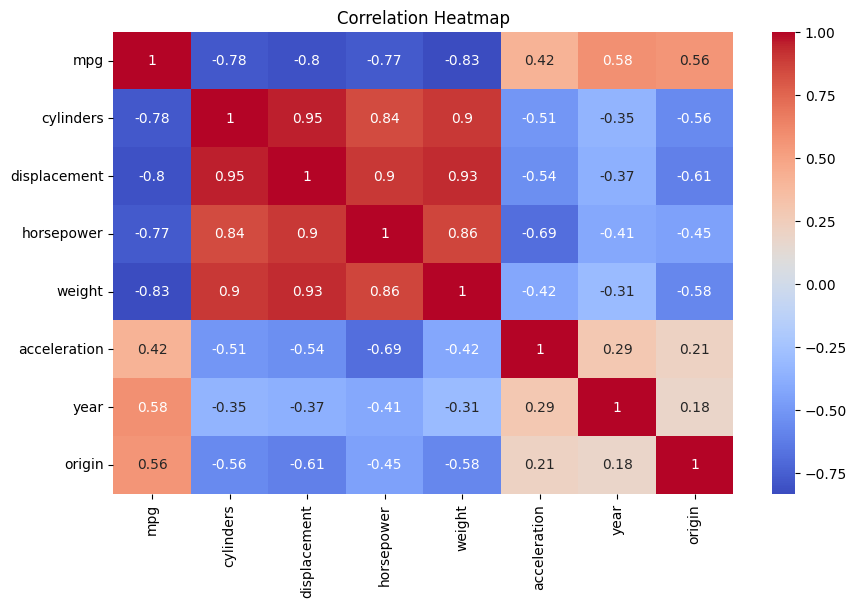

In [86]:
#5
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [88]:
#7
columns_to_drop = ['name']
if set(columns_to_drop).issubset(df.columns):
    df.drop(columns=columns_to_drop, inplace=True)

print("\nХасагдсан баганууд:", columns_to_drop)



Хасагдсан баганууд: ['name']


In [89]:
#8
if 'weight' in df.columns:
    df.insert(len(df.columns), 'weight_kg', (df['weight'] * 0.4535924).astype(int))

print("\nШинэ багана нэмэгдсэн: weight_kg")
df.head()


Шинэ багана нэмэгдсэн: weight_kg


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,weight_kg
0,18.0,8,307.0,130.0,3504,12.0,70,1,1589
1,15.0,8,350.0,165.0,3693,11.5,70,1,1675
2,18.0,8,318.0,150.0,3436,11.0,70,1,1558
3,16.0,8,304.0,150.0,3433,12.0,70,1,1557
4,17.0,8,302.0,140.0,3449,10.5,70,1,1564


In [90]:
#9
from scipy.stats import zscore

df_normalized = df.select_dtypes(include=[np.number]).apply(zscore)

print("\nНормчлогдсон өгөгдлийн эхний 5 мөр:")
df_normalized.head()


Нормчлогдсон өгөгдлийн эхний 5 мөр:


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,weight_kg
0,-0.706439,1.498191,1.090604,0.673118,0.630870,-1.295498,-1.627426,-0.715145,0.631171
1,-1.090751,1.498191,1.503514,1.589958,0.854333,-1.477038,-1.627426,-0.715145,0.855339
2,-0.706439,1.498191,1.196232,1.197027,0.550470,-1.658577,-1.627426,-0.715145,0.550367
3,-0.962647,1.498191,1.061796,1.197027,0.546923,-1.295498,-1.627426,-0.715145,0.547760
4,-0.834543,1.498191,1.042591,0.935072,0.565841,-1.840117,-1.627426,-0.715145,0.566006


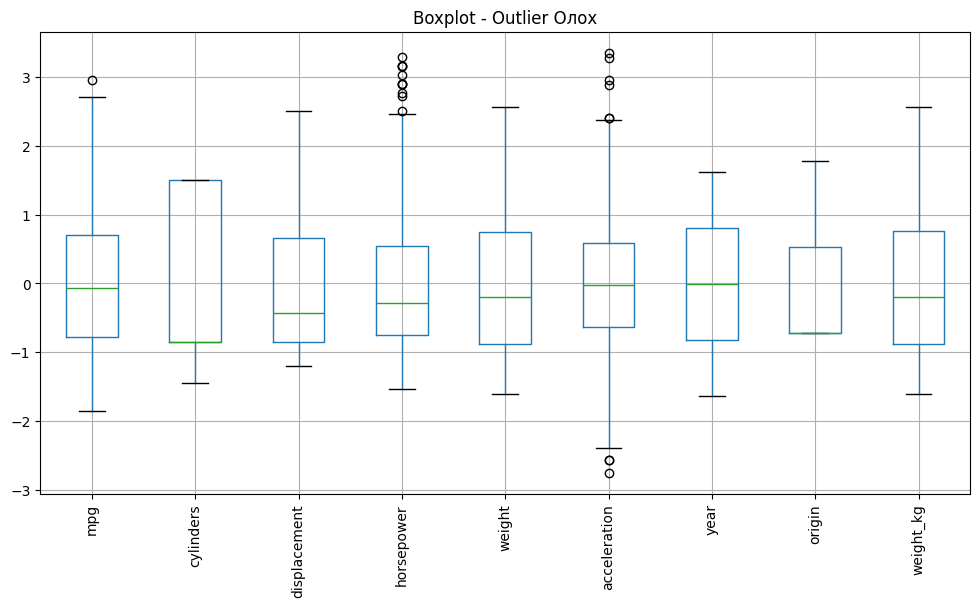

In [91]:
#10
plt.figure(figsize=(12, 6))
df_normalized.boxplot(rot=90)
plt.title("Boxplot - Outlier Олох")
plt.show()

In [92]:

Q1 = df_normalized.quantile(0.25)
Q3 = df_normalized.quantile(0.75)
IQR = Q3 - Q1

outlier = (df_normalized < (Q1 - 1.5 * IQR)) | (df_normalized > (Q3 + 1.5 * IQR))

new_df = df_normalized[~outlier.any(axis=1)]

initial_data_count = df_normalized.shape[0]
final_data_count = new_df.shape[0]
removed_data_count = initial_data_count - final_data_count

print(f"Нийт өгөгдөл: {initial_data_count}")
print(f"Устгасан өгөгдөл: {removed_data_count}")
print(f"Outlier устгасны дараах өгөгдлийн тоо: {final_data_count}")


Нийт өгөгдөл: 398
Устгасан өгөгдөл: 20
Outlier устгасны дараах өгөгдлийн тоо: 378


In [93]:
new_df

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,weight_kg
0,-0.706439,1.498191,1.090604,0.673118,0.630870,-1.295498,-1.627426,-0.715145,0.631171
1,-1.090751,1.498191,1.503514,1.589958,0.854333,-1.477038,-1.627426,-0.715145,0.855339
2,-0.706439,1.498191,1.196232,1.197027,0.550470,-1.658577,-1.627426,-0.715145,0.550367
3,-0.962647,1.498191,1.061796,1.197027,0.546923,-1.295498,-1.627426,-0.715145,0.547760
4,-0.834543,1.498191,1.042591,0.935072,0.565841,-1.840117,-1.627426,-0.715145,0.566006
...,...,...,...,...,...,...,...,...,...
392,0.446497,-0.856321,-0.407398,-0.374700,-0.024149,0.628820,1.621983,-0.715145,-0.023086
393,0.446497,-0.856321,-0.513026,-0.479482,-0.213324,0.011586,1.621983,-0.715145,-0.213368
395,1.087017,-0.856321,-0.561039,-0.531873,-0.798585,-1.440730,1.621983,-0.715145,-0.799854
396,0.574601,-0.856321,-0.705077,-0.662850,-0.408411,1.100822,1.621983,-0.715145,-0.408864


In [95]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(new_df)

df_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])

print("\nPCA-гаар хөрвүүлсэн өгөгдөл:")
print(df_pca.head())


PCA-гаар хөрвүүлсэн өгөгдөл:
        PC1       PC2
0  2.827957 -1.216017
1  3.648656 -1.269139
2  3.052938 -1.326144
3  3.021030 -1.320899
4  2.999105 -1.385160
